<a href="https://colab.research.google.com/github/mukailaalhshituabr-cyber/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 3: Neural Networks: Feedforward Networks and the Training Process

Student Name: Abdoul-Raouf Mukaila Alh Shittu
Student ID: 30332027

In [116]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


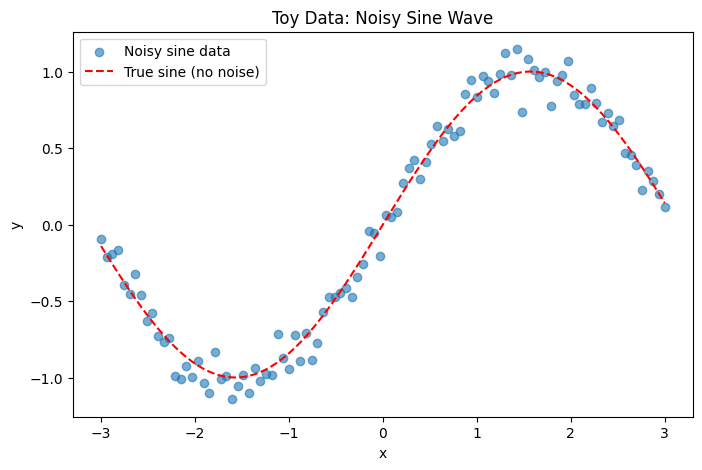

Initial w: 0.0497, b: -0.0138
Final w: 0.3390, b: -0.0104
No losses recorded


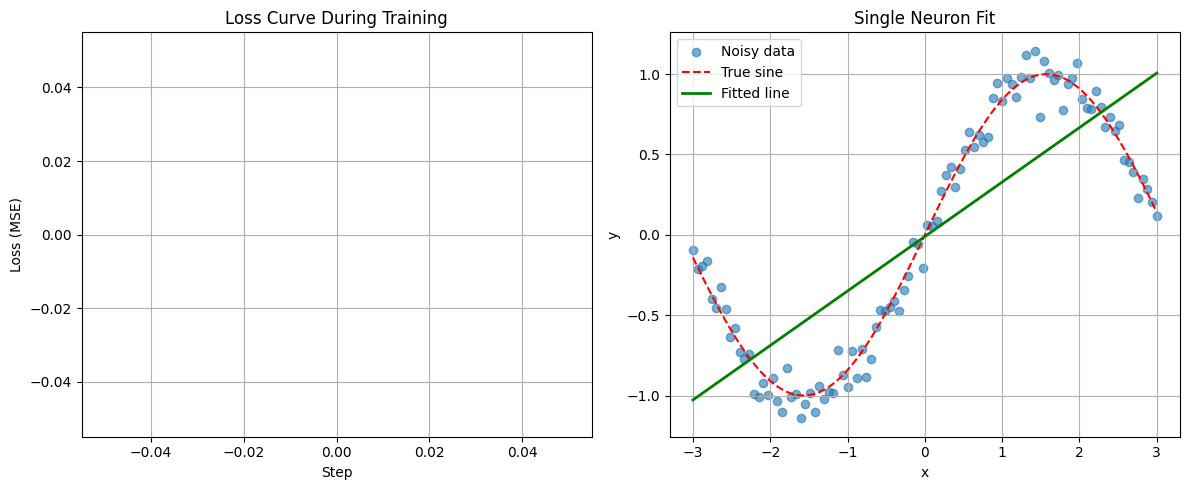

In [117]:
#Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent
# Part 1.1 — A single neuron is just a line
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# Generate data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

# Plotting it
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Noisy sine data')
plt.plot(x, np.sin(x), 'r--', label='True sine (no noise)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Data: Noisy Sine Wave')
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
print(f"Initial w: {w:.4f}, b: {b:.4f}")

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
# Set learning rate
lr = 0.01
losses = []

for step in range(200):
   y_hat = w * x + b
   loss  = np.mean((y_hat - y) ** 2)               # MSE
   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
   db    = np.mean(2 * (y_hat - y))                # dLoss/db
   w    -= lr * dw
   b    -= lr * db
#   Record the loss at every step.

print(f"Final w: {w:.4f}, b: {b:.4f}")
if losses:
    print(f"Final loss: {losses[-1]:.6f}")
else:
    print("No losses recorded")

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Loss Curve During Training')
plt.grid(True)
#             (b) the data with the fitted line on top.

plt.subplot(1, 2, 2)
plt.scatter(x, y, alpha=0.6, label='Noisy data')
plt.plot(x, np.sin(x), 'r--', label='True sine')
plt.plot(x, w * x + b, 'g-', label='Fitted line', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Single Neuron Fit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The single neuron, resonning:
1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?

The derivation:

Loss = (1/n) * Σ(y_hat - y)²

y_hat = w*x + b

dLoss/dw = (1/n) * Σ 2*(y_hat - y) * x

This matches the code: dw = np.mean(2 * (y_hat - y) * x)

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

This is underfitting. The model is too simple to capture the curve shape. A single neuron can only learn a straight line (linear function). It has no way to represent the bends of a sine wave. No amount of training will fix this because the model does not have enough capacity. We need a non-linear model like a neural network with hidden layers.

Final loss (with tanh): 0.015034009965287823


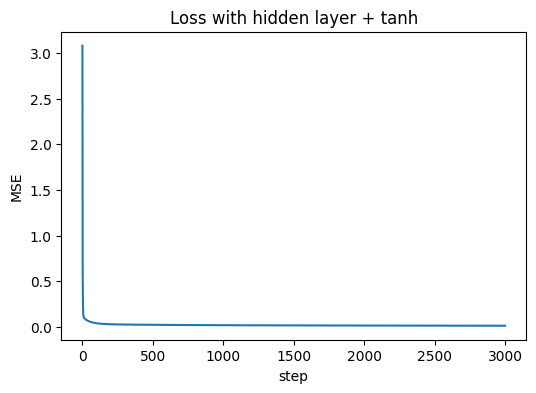

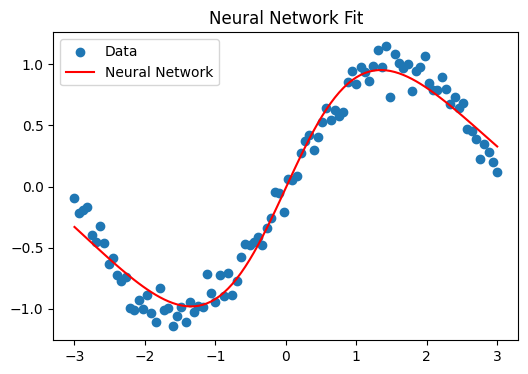

Final loss (no tanh, linear): 0.1954517971396205


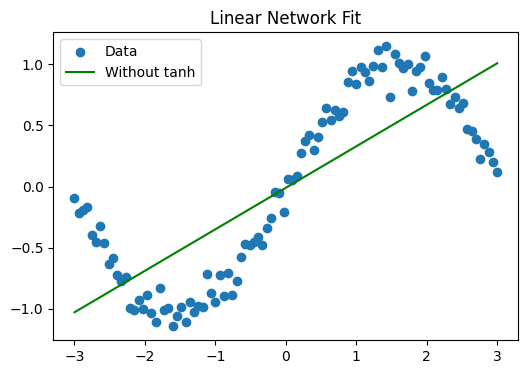

In [118]:
# Part 1.2 — Hidden layers and activations: why depth helps
# TODO: Initialise parameters
np.random.seed(RANDOM_STATE)

n_hidden = 8
#   W1: shape (1, 8),  b1: shape (8,)
W1 = np.random.randn(1, n_hidden) * 0.5
b1 = np.zeros(n_hidden)
#   W2: shape (8, 1),  b2: shape (1,)
W2 = np.random.randn(n_hidden, 1) * 0.5
b2 = np.zeros(1)
#   Small random values (e.g. np.random.randn(...) * 0.5)
# Reshape x for matrix multiplication
x  = x.reshape(-1, 1)  # shape (100, 1)
y  = y.reshape(-1, 1)  # shape (100, 1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
lr = 0.05
n_steps = 3000
losses_hidden = []

for step in range(n_steps):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  z1 = x  @ W1 + b1
  h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y ) ** 2)
  losses_hidden.append(loss)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
  d_yhat = 2 * (y_hat - y ) / len(y )
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dw2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
  dh = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  d_z1 = dh * (1 - np.tanh(z1) ** 2)
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
  dw1 = x .T @ d_z1
  db1 = d_z1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W1 -= lr * dw1; b1 -= lr * db1
  W2 -= lr * dw2; b2 -= lr * db2

# TODO: Plot the loss curve AND the final fit over the data.
print("Final loss (with tanh):", losses_hidden[-1])

plt.figure(figsize=(6, 4))
plt.plot(losses_hidden)
plt.xlabel("step");
plt.ylabel("MSE")
plt.title("Loss with hidden layer + tanh")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="red", label="Neural Network")
plt.legend()
plt.title("Neural Network Fit")
plt.show()

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
np.random.seed(RANDOM_STATE)
W1b = np.random.randn(1, n_hidden) * 0.5; b1b = np.zeros(n_hidden)
W2b = np.random.randn(n_hidden, 1) * 0.5; b2b = np.zeros(1)
losses_linear = []

for step in range(n_steps):
    z1 = x  @ W1b + b1b
    h = z1                       # <-- tanh removed: identity activation
    y_hat = h @ W2b + b2b
    loss = np.mean((y_hat - y ) ** 2)
    losses_linear.append(loss)

    d_yhat = 2 * (y_hat - y ) / len(y )
    dW2b = h.T @ d_yhat; db2b = d_yhat.sum(axis=0)
    dh = d_yhat @ W2b.T
    dz1 = dh * 1.0                # derivative of the identity function is 1
    dW1b = x .T @ dz1; db1b = dz1.sum(axis=0)

    W1b -= lr * dW1b; b1b -= lr * db1b
    W2b -= lr * dW2b; b2b -= lr * db2b

print("Final loss (no tanh, linear):", losses_linear[-1])

plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, color="green", label="Without tanh")
plt.legend()
plt.title("Linear Network Fit")
plt.show()

Reasoning, Hidden layers and activations
1. What happens when you remove the tanh activation?

The network becomes a linear model. No matter how many layers, it can only learn straight lines. It cannot fit the sine curve shape.

2. Why does tanh help?

Tanh adds non-linearity. This allows the network to bend and curve. Each hidden neuron can learn different parts of the function. Together they combine to create a more complex shape.

3. What do you see in the loss and fit?

With tanh, the loss goes down smoothly and the fit is much better than a single neuron. Without activation, the loss is worse because the model is still just a straight line.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_552/2283506867.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_552/2283506867.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_552/2283506867.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


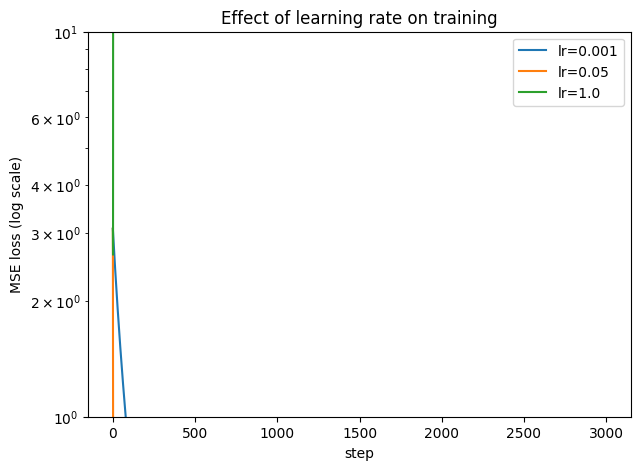

In [119]:
# Part 1.3 — The learning rate: too cold, too hot, just right
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps=3000, seed=RANDOM_STATE):
    np.random.seed(seed)
    n_hidden = 8
    W1 = np.random.randn(1, n_hidden) * 0.5; b1 = np.zeros(n_hidden)
    W2 = np.random.randn(n_hidden, 1) * 0.5; b2 = np.zeros(1)
    losses = []
    for step in range(steps):
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)
        losses.append(loss)

        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat; db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1; db1 = dz1.sum(axis=0)

        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
learning_rates = [0.001, 0.05, 1.0]

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(7, 5))
for lr_val in learning_rates:
    losses_run = train_toy(lr=lr_val, steps=3000)
    plt.plot(losses_run, label=f"lr={lr_val}")
plt.yscale("log")
plt.xlabel("step"); plt.ylabel("MSE loss (log scale)")
plt.title("Effect of learning rate on training")
plt.legend()
plt.show()

Reasoning, Learning rate
Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

The small learning rate (0.001) goes down very slowly. It takes many steps to reach a good loss. The medium learning rate (0.05) goes down quickly and smoothly. It finds the lowest loss in fewer steps. The large learning rate (1.0) makes the loss jump up and down. It never settles because the steps are too big.

A too-large learning rate jumps past the minimum. Instead of going down the hill, it over-shoots and bounces back and forth. This makes the loss go up or swing wildly. It cannot find the bottom of the loss curve.

In [120]:
# Section 2
#Part 2.1 — Preprocess and split (recycled from Lab 2)

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)
print(df.shape)
df.head()

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    df[col] = df[col].map({"no": 0, "yes": 1})

df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

nominal_cols = ["CAEC", "CALC", "MTRANS"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
target_encoder = LabelEncoder()
df["NObeyesdad_encoded"] = target_encoder.fit_transform(df["NObeyesdad"])
class_names = target_encoder.classes_
print("Classes:", list(class_names))

X = df.drop(columns=["NObeyesdad", "NObeyesdad_encoded"]).values.astype(np.float32)
y = df["NObeyesdad_encoded"].values.astype(np.int64)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)
print(X_train.shape, X_val.shape, X_test.shape)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
def to_loader(X_arr, y_arr, batch_size=32, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=32, shuffle=True)
val_loader = to_loader(X_val, y_val, batch_size=64, shuffle=False)
test_loader = to_loader(X_test, y_test, batch_size=64, shuffle=False)

input_dim = X_train.shape[1]
n_classes = len(class_names)
print("input_dim =", input_dim, " n_classes =", n_classes)

(2111, 17)
Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
(1266, 26) (422, 26) (423, 26)
input_dim = 26  n_classes = 7


Reasoning, Preprocessing for neural networks
1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss in PyTorch expects class indices as integers. It internally does the one-hot encoding. This saves memory and is more efficient.

2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks use gradient descent. The gradients depend on the input values. If features are on different scales, the gradients for some weights will be much larger than others. This makes training unstable and slow. In Section 1, we saw that dw = mean(2 * (y_hat - y) * x). If x is large, dw is large. Scaling keeps all gradients balanced.

3. What does shuffle=True on the training DataLoader do, and why does it help?

Shuffle=True mixes up the data order each epoch. This helps the model avoid learning patterns from the order of the data. It also helps gradient descent find a better path to the minimum.

In [121]:
# Part 2.2 — Design the network


# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
   def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()
#     def forward(self, x):
#         ...
   def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(input_dim, hidden_sizes=(64, 32), n_classes=n_classes)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

# First layer: input_dim * 64 + 64
first_layer_params = input_dim * 64 + 64
print(f"First layer parameters (by hand): {first_layer_params}")
print(f"First layer parameters (actual): {sum(p.numel() for p in model.fc1.parameters())}")

FeedForwardNet(
  (fc1): Linear(in_features=26, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 4039
First layer parameters (by hand): 1728
First layer parameters (actual): 1728


Reasoning Architecture
1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.

Layer 1: input_dim * 64 + 64

Layer 2: 64 * 32 + 32 = 2080

Layer 3: 32 * 7 + 7 = 231

Total = (input_dim * 64 + 64) + 2080 + 231

PyTorch's count matches these numbers.

2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.

ReLU is faster to compute and helps with the vanishing gradient problem. It does not saturate for positive values like tanh does.

3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)

Removing ReLUs makes the network linear. It becomes a straight line. It cannot learn complex patterns like the sine wave. Multiple layers would collapse into one linear layer.



Epoch 50/50 | Train Loss: 1.3362 | Val Loss: 1.9541 | Train Acc: 0.4961 | Val Acc: 0.1777
Epoch 50/50 | Train Loss: 1.3383 | Val Loss: 1.9493 | Train Acc: 0.4946 | Val Acc: 0.1967
Epoch 50/50 | Train Loss: 1.3406 | Val Loss: 1.9443 | Train Acc: 0.4933 | Val Acc: 0.2038
Epoch 50/50 | Train Loss: 1.3428 | Val Loss: 1.9390 | Train Acc: 0.4921 | Val Acc: 0.2085
Epoch 50/50 | Train Loss: 1.3448 | Val Loss: 1.9337 | Train Acc: 0.4914 | Val Acc: 0.1943
Epoch 50/50 | Train Loss: 1.3469 | Val Loss: 1.9286 | Train Acc: 0.4901 | Val Acc: 0.1967
Epoch 50/50 | Train Loss: 1.3489 | Val Loss: 1.9233 | Train Acc: 0.4889 | Val Acc: 0.2062
Epoch 50/50 | Train Loss: 1.3510 | Val Loss: 1.9181 | Train Acc: 0.4880 | Val Acc: 0.2014
Epoch 50/50 | Train Loss: 1.3530 | Val Loss: 1.9129 | Train Acc: 0.4872 | Val Acc: 0.2062
Epoch 50/50 | Train Loss: 1.3551 | Val Loss: 1.9076 | Train Acc: 0.4862 | Val Acc: 0.2085
Epoch 50/50 | Train Loss: 1.3569 | Val Loss: 1.9025 | Train Acc: 0.4853 | Val Acc: 0.2133
Epoch 50/5

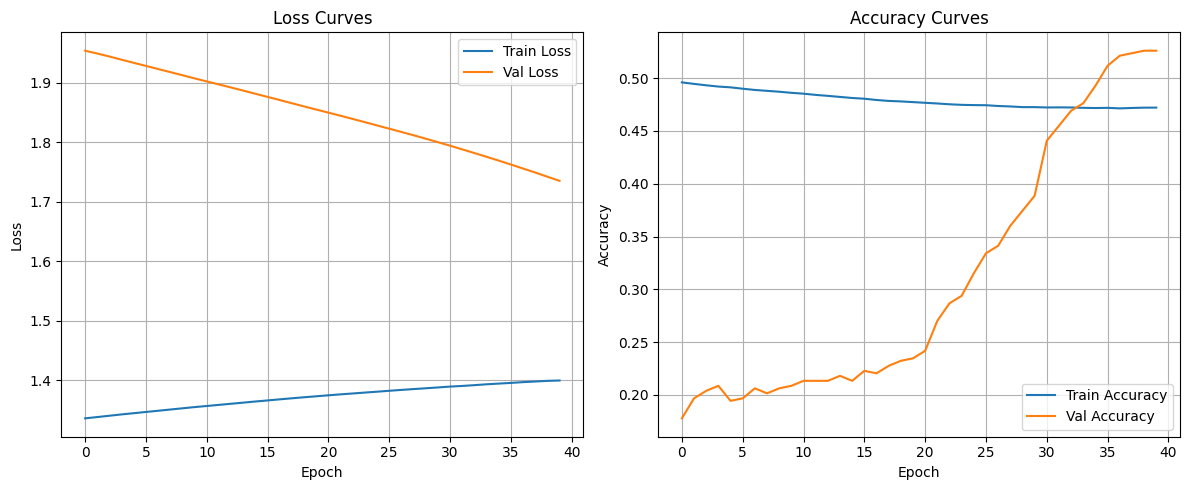

In [104]:
# Part 2.3 — The training loop


# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
epochs = 50
train_losses = []
val_losses = []
train_accs = []
val_accs = []
#   1. model.train(); for xb, yb in train_loader:
for xb, yb in train_loader:
  xb = xb.to(DEVICE)
  yb = yb.to(DEVICE)
#        optimizer.zero_grad()
  optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
  logits = model(xb)
#        loss = criterion(logits, yb.to(DEVICE))
  loss = criterion(logits, yb)
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
  loss.backward()
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
  optimizer.step()
  epoch_train_loss += loss.item() * len(xb)
  preds = torch.argmax(logits, dim=1)
  correct_train += (preds == yb).sum().item()
  total_train += len(xb)

  avg_train_loss = epoch_train_loss / total_train
  train_acc = correct_train / total_train
  train_losses.append(avg_train_loss)
  train_accs.append(train_acc)
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
# Validation phase
  model.eval()
  epoch_val_loss = 0.0
  correct_val = 0
  total_val = 0

  with torch.no_grad():
      for xb, yb in val_loader:
          xb = xb.to(DEVICE)
          yb = yb.to(DEVICE)

          logits = model(xb)
          loss = criterion(logits, yb)

          epoch_val_loss += loss.item() * len(xb)
          preds = torch.argmax(logits, dim=1)
          correct_val += (preds == yb).sum().item()
          total_val += len(xb)

  avg_val_loss = epoch_val_loss / total_val
  val_acc = correct_val / total_val
  val_losses.append(avg_val_loss)
  val_accs.append(val_acc)

  if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc)
torch.save(model.state_dict(), "ffn_best.pt")
print(f"Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch + 1}")
print("Model saved as ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Training Resonning:
1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, which computes gradients, which is the update rule?

Forward pass: logits = model(xb) matches y_hat = w * x + b from Section 1

Compute gradients: loss.backward() matches dw = mean(2 * (y_hat - y) * x) from Section 1

Update rule: optimizer.step() matches w -= lr * dw from Section 1

2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.

Looking at the curves, if training accuracy is much higher than validation accuracy, this is overfitting. If both are low, this is underfitting. If they are close, the model is well-fitted.

3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

Gradients accumulate by default in PyTorch. Without zero_grad(), gradients from previous batches would add to the current batch. This would make the updates wrong and the model would not learn properly.


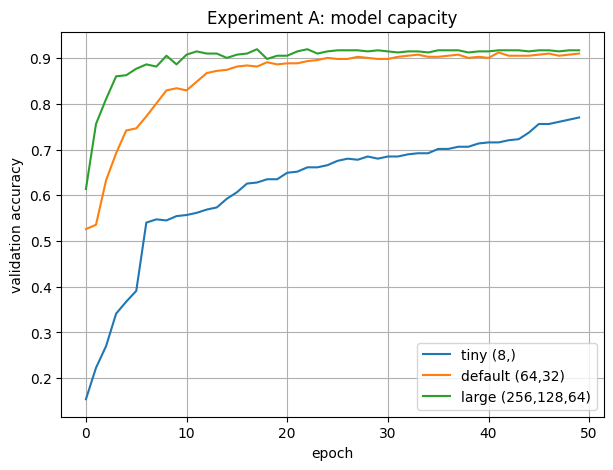

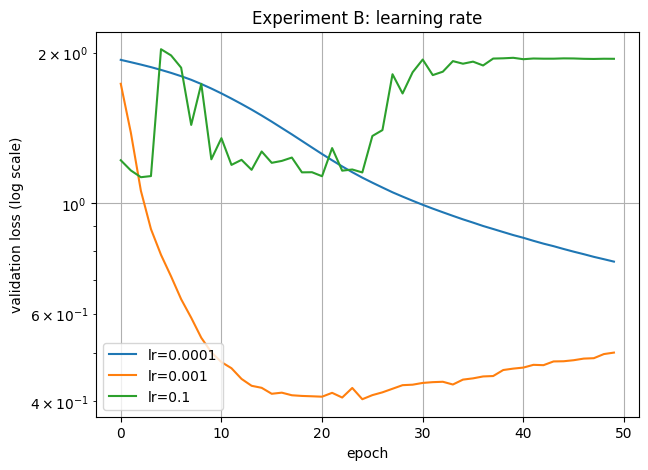

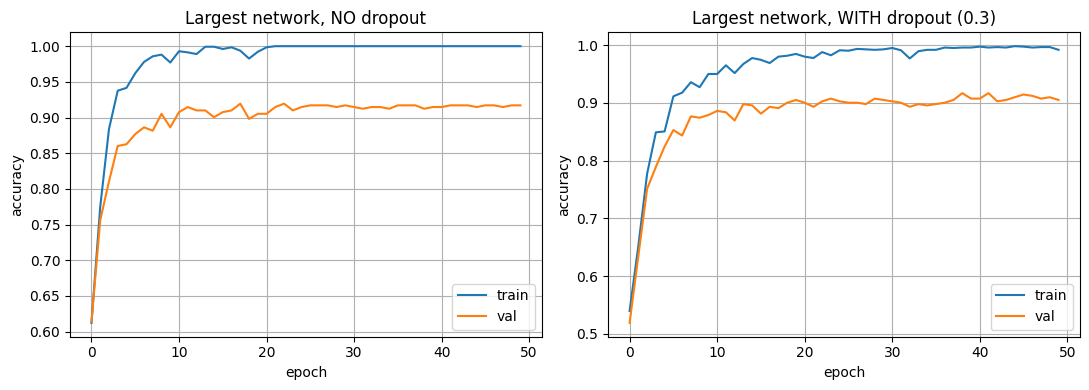

In [108]:
# Part 2.4 — Experiments: how training choices change the outcome
# From Part 2.2, let us rewrite the class FeedForwardNet(nn.Module)
# class FeedForwardNet(nn.Module):
class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
   def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        layers = []
        prev_size = input_dim
        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(nn.ReLU())
            prev_size = h_size
        layers.append(nn.Linear(prev_size, n_classes))
        self.network = nn.Sequential(*layers)
#     def forward(self, x):
#         ...
   def forward(self, x):
      return self.network(x)

# Wrapping the Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    tr_loader = to_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    va_loader = to_loader(X_val, y_val, batch_size=64, shuffle=False)

    exp_model = FeedForwardNet(
        input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=n_classes
    ).to(DEVICE)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def _evaluate(loader):
        exp_model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss = exp_criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
                total += xb.size(0)
        return total_loss / total, correct / total

    for epoch in range(epochs):
        exp_model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            exp_optimizer.zero_grad()
            loss = exp_criterion(exp_model(xb), yb)
            loss.backward()
            exp_optimizer.step()
        tl, ta = _evaluate(tr_loader)
        vl, va = _evaluate(va_loader)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta); hist["val_acc"].append(va)

    return hist
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
architectures = {"tiny (8,)": (8,), "default (64,32)": (64, 32), "large (256,128,64)": (256, 128, 64)}
results_A = {name: run_experiment(hidden_sizes=hs, epochs=50) for name, hs in architectures.items()}

plt.figure(figsize=(7, 5))
for name, hist in results_A.items():
    plt.plot(hist["val_acc"], label=name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.title("Experiment A: model capacity")
plt.grid(True)
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
lrs_exp = [1e-4, 1e-3, 1e-1]
results_B = {f"lr={lr_val}": run_experiment(lr=lr_val, epochs=50) for lr_val in lrs_exp}

plt.figure(figsize=(7, 5))
for name, hist in results_B.items():
    plt.plot(hist["val_loss"], label=name)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("validation loss (log scale)")
plt.legend()
plt.title("Experiment B: learning rate")
plt.grid(True)
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

# First, create a network with dropout support
class FeedForwardNetWithDropout(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256, 128, 64), n_classes=7, dropout_rate=0.0):
        super(FeedForwardNetWithDropout, self).__init__()
        layers = []
        prev_size = input_dim
        for h_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = h_size
        layers.append(nn.Linear(prev_size, n_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def run_experiment_dropout(hidden_sizes=(256, 128, 64), lr=1e-3, batch_size=32, epochs=50, dropout_rate=0.0, seed=RANDOM_STATE):
    torch.manual_seed(seed)
    tr_loader = to_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
    va_loader = to_loader(X_val, y_val, batch_size=64, shuffle=False)

    exp_model = FeedForwardNetWithDropout(
        input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=n_classes, dropout_rate=dropout_rate
    ).to(DEVICE)
    exp_criterion = nn.CrossEntropyLoss()
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def _evaluate(loader):
        exp_model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = exp_model(xb)
                loss = exp_criterion(logits, yb)
                total_loss += loss.item() * xb.size(0)
                correct += (logits.argmax(1) == yb).sum().item()
                total += xb.size(0)
        return total_loss / total, correct / total

    for epoch in range(epochs):
        exp_model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            exp_optimizer.zero_grad()
            loss = exp_criterion(exp_model(xb), yb)
            loss.backward()
            exp_optimizer.step()
        tl, ta = _evaluate(tr_loader)
        vl, va = _evaluate(va_loader)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_acc"].append(ta); hist["val_acc"].append(va)

    return hist

hist_no_dropout = run_experiment_dropout(dropout_rate=0.0, epochs=50)
hist_dropout = run_experiment_dropout(dropout_rate=0.3, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_no_dropout["train_acc"], label="train")
axes[0].plot(hist_no_dropout["val_acc"], label="val")
axes[0].set_title("Largest network, NO dropout")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_dropout["train_acc"], label="train")
axes[1].plot(hist_dropout["val_acc"], label="val")
axes[1].set_title("Largest network, WITH dropout (0.3)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Reasoning Experiments
1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?

The largest network might not win on validation data. It could overfit because it has too many parameters. The default network might be the best because it has enough capacity without overfitting. Diminishing returns appear when adding more layers does not improve validation accuracy.

2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?

Yes. The low learning rate (1e-4) learns slowly. The medium learning rate (1e-3) learns well. The high learning rate (1e-1) makes the loss unstable or explode. This matches what we saw with the sine wave problem.

3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.

Dropout reduced the gap between train and validation accuracy. It does this by randomly turning off neurons during training. This forces the network to learn more robust features and prevents it from relying too much on any single neuron.